In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
import numpy as np


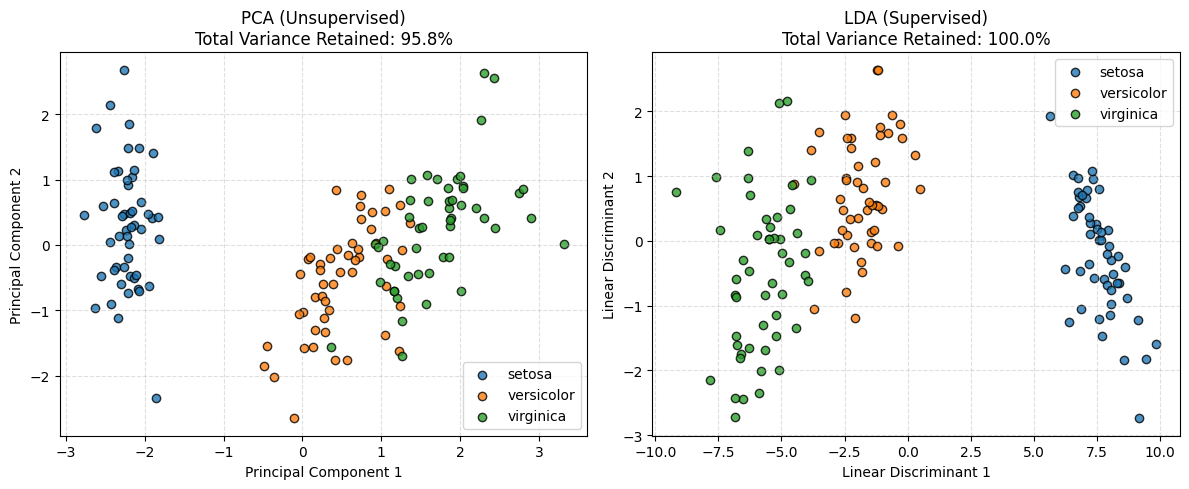

PCA Variance Ratios: Component 1 = 0.730, Component 2 = 0.229
LDA Variance Ratios: Component 1 = 0.991, Component 2 = 0.009


In [ ]:
iris=load_iris()
X ,y=iris.data,iris.target
target_names=iris.target_names

X_scaled=StandardScaler().fit_transform(X)

pca=PCA(n_components=2)
X_pca=pca.fit_transform(X_scaled)

lda=LinearDiscriminantAnalysis(n_components=2)
X_lda=lda.fit_transform(X_scaled,y)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i,color,name in zip(range(3),colors,target_names):
    ax1.scatter(X_pca[y == i, 0], X_pca[y == i, 1], alpha=0.8, c=color, label=name, edgecolors='k')
ax1.set_title(f'PCA (Unsupervised)\nTotal Variance Retained: {sum(pca.explained_variance_ratio_)*100:.1f}%')
ax1.set_xlabel('Principal Component 1')
ax1.set_ylabel('Principal Component 2')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.4)

for i, color, name in zip(range(3), colors, target_names):
    ax2.scatter(X_lda[y == i, 0], X_lda[y == i, 1], color=color, alpha=0.8, label=name, edgecolors='k')
ax2.set_title(f'LDA (Supervised)\nTotal Variance Retained: {sum(lda.explained_variance_ratio_)*100:.1f}%')
ax2.set_xlabel('Linear Discriminant 1')
ax2.set_ylabel('Linear Discriminant 2')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print(f"PCA Variance Ratios: Component 1 = {pca.explained_variance_ratio_[0]:.3f}, Component 2 = {pca.explained_variance_ratio_[1]:.3f}")
print(f"LDA Variance Ratios: Component 1 = {lda.explained_variance_ratio_[0]:.3f}, Component 2 = {lda.explained_variance_ratio_[1]:.3f}")